# Compare Tropical Work (Control vs +4K, Prate Thresholded)

Python notebook translation of `matlab/entries/compare_tropical_work_control_vs_plus4k_prate_thresholded.m`.

This first pass uses translated modules in `python/translated_from_matlab`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'python'))

from translated_from_matlab.analysis.plotting import plot_percentile_bin_ratio_comparison
from translated_from_matlab.analysis.thresholded_bin_stats import ThresholdedRunConfig, compute_thresholded_bin_stats
from translated_from_matlab.presets.regions import region_tropics
from translated_from_matlab.presets.scenarios import scenario_control, scenario_plus4k

In [2]:
cfg_ctrl = ThresholdedRunConfig(scenario=scenario_control(), region=region_tropics())
cfg_warm = ThresholdedRunConfig(scenario=scenario_plus4k(), region=region_tropics())

print('=== Computing bin stats: Control ===')
stats_ctrl = compute_thresholded_bin_stats(cfg_ctrl).stats

print('=== Computing bin stats: +4K ===')
stats_warm = compute_thresholded_bin_stats(cfg_warm).stats

=== Computing bin stats: Control ===


/home/mbolot/.conda/envs/easyclim/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Computing bin stats: +4K ===


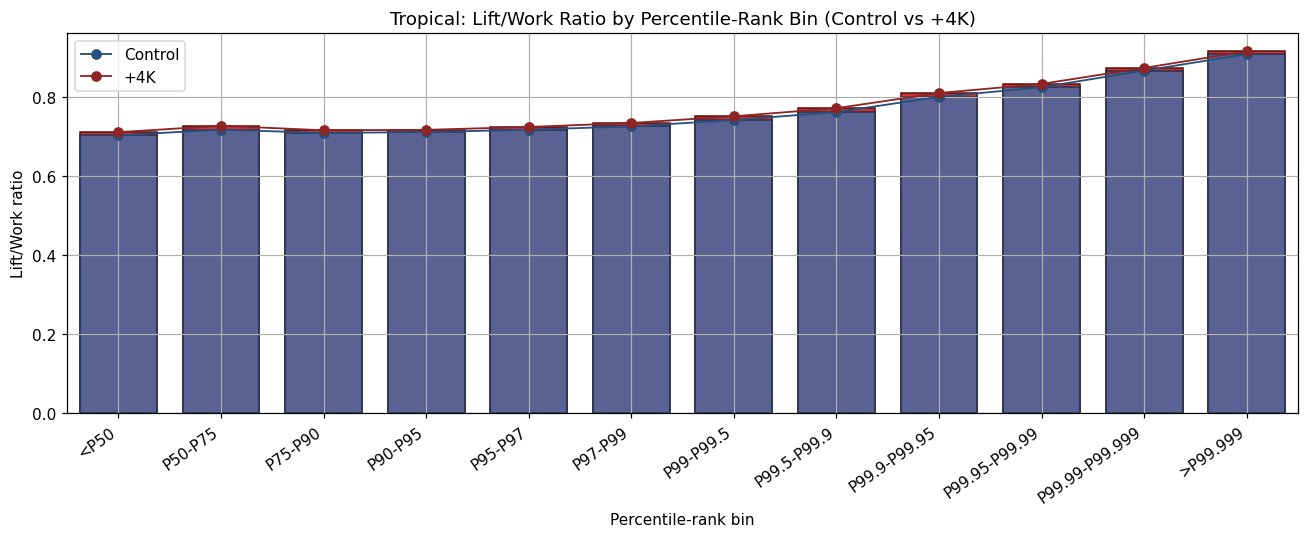

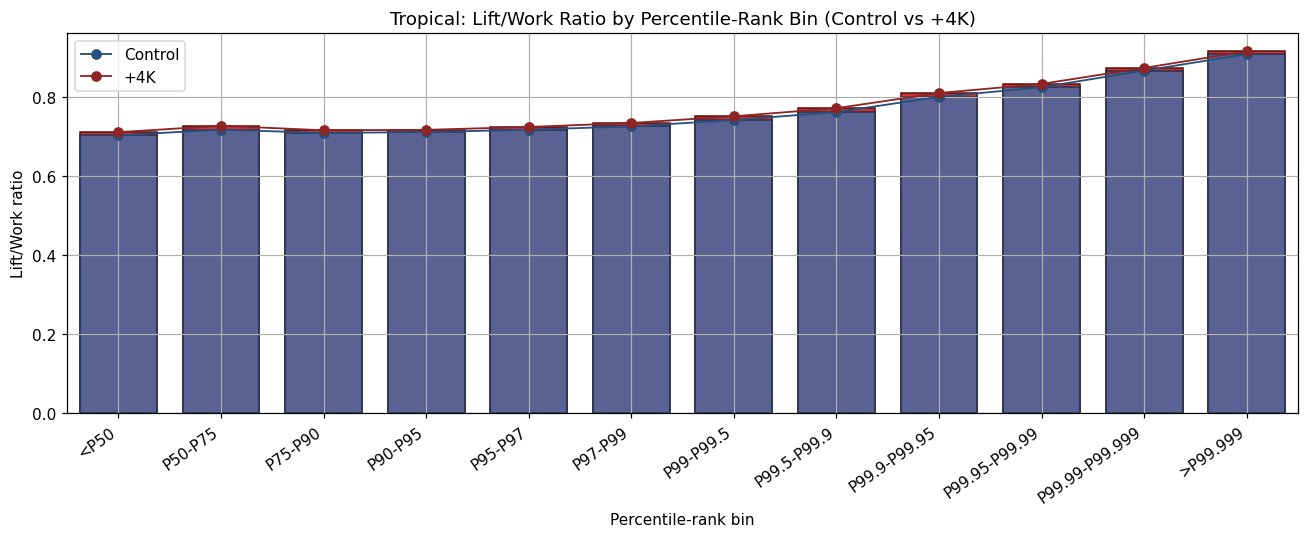

In [3]:
fig, ax = plot_percentile_bin_ratio_comparison(
    stats_ctrl,
    stats_warm,
    region_title=cfg_ctrl.region.title_label,
    label_ctrl='Control',
    label_warm='+4K',
)
fig

In [4]:
import pandas as pd

summary = pd.DataFrame({
    'bin_label': stats_ctrl.labels,
    'ratio_control': stats_ctrl.ratio_bin,
    'ratio_plus4k': stats_warm.ratio_bin,
})
summary['delta_plus4k_minus_control'] = summary['ratio_plus4k'] - summary['ratio_control']
summary

,bin_label,ratio_control,ratio_plus4k,delta_plus4k_minus_control
0,<P50,0.702774,0.710613,0.007839
1,P50-P75,0.716954,0.726803,0.009848
2,P75-P90,0.708794,0.715414,0.006619
3,P90-P95,0.710783,0.716555,0.005772
4,P95-P97,0.716973,0.723857,0.006884
5,P97-P99,0.725278,0.733883,0.008605
6,P99-P99.5,0.741288,0.750835,0.009547
7,P99.5-P99.9,0.761514,0.771247,0.009733
8,P99.9-P99.95,0.799826,0.809576,0.009750
9,P99.95-P99.99,0.824310,0.832725,0.008415
